# ShopEase Europe - Notebook 10: Summarisation and Interactive Dashboard
**Project:** Sentiment Analysis for Customer Feedback
**Stage:** Automated Summarisation + Interactive Dashboard (Sections 11 and 12 of brief)
**Dataset:** amazon_reviews_cleaned.csv

This notebook covers two sections from the project brief:

**Section 11 - Automated Summarisation:**
- Extractive summarisation using TF-IDF cosine similarity to the corpus centroid
- Abstractive summarisation using BART (transformer-based)
- Executive summary, country-level summaries, and category-level summaries

**Section 12 - Interactive Dashboard:**
- Executive KPI cards (total reviews, Positive, Negative, Neutral, average rating)
- Sentiment trend chart
- Country sentiment chart
- Product category analysis
- Topic distribution

In [1]:
%pip install pandas numpy matplotlib seaborn plotly wordcloud nltk textblob scikit-learn transformers --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 10.1 Load Libraries and Data

In [2]:
import re, pickle, os, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
warnings.filterwarnings('ignore')
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from textblob import TextBlob
for pkg in ['punkt','stopwords','wordnet','punkt_tab','vader_lexicon','omw-1.4']:
    nltk.download(pkg, quiet=True)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
PALETTE = {'Positive': '#2ecc71', 'Neutral': '#3498db', 'Negative': '#e74c3c'}
COUNTRY_NAMES = {
    'US': 'United States', 'GB': 'United Kingdom', 'CA': 'Canada',
    'IN': 'India', 'IE': 'Ireland', 'DK': 'Denmark', 'NL': 'Netherlands',
    'AU': 'Australia', 'DE': 'Germany', 'IT': 'Italy', 'FR': 'France',
    'SE': 'Sweden', 'ES': 'Spain', 'AE': 'United Arab Emirates'
}

df = pd.read_csv('../data/processed/amazon_reviews_cleaned_processed.csv')
df.columns = [c.strip().lower().replace(' ', '_') for c in df.columns]
for col in ['sentiment','country','product_category']:
    df[col] = df[col].str.strip()
df['sentiment'] = df['sentiment'].str.capitalize()
df['timestamp'] = pd.to_datetime(df['timestamp'], format='ISO8601', utc=True)
df['year']       = df['timestamp'].dt.year
df['month']      = df['timestamp'].dt.month
df['year_month'] = df['timestamp'].dt.to_period('M').astype(str)
df = df.dropna(subset=['country']).reset_index(drop=True)
df = df.drop_duplicates(subset='review', keep='first').reset_index(drop=True)

lemmatizer = WordNetLemmatizer()
STOPS = set(stopwords.words('english')) | {
    'product','item','ordered','order','amazon','purchase',
    'bought','buy','would','also','one','get','got','use',
    'used','using','review','star','stars','rating'}

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'https?\S+|www\.\S+', ' ', text)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = word_tokenize(text)
    return ' '.join([lemmatizer.lemmatize(t) for t in tokens if t not in STOPS and len(t) > 2])

df['clean_review'] = df['review'].apply(clean_text)
vader = SentimentIntensityAnalyzer()
df['vader_compound'] = df['review'].apply(lambda x: vader.polarity_scores(x)['compound'])
df['word_count']     = df['review'].apply(lambda x: len(x.split()))
df['char_count']     = df['review'].apply(len)
print(f"Dataset ready: {len(df):,} rows")

Dataset ready: 20,406 rows


## 10.2 Extractive Summarisation

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def extractive_summary(df_subset, n=5):
    # Drop rows where either column is null so indices stay aligned
    clean_df = df_subset[['review', 'clean_review']].dropna()

    if len(clean_df) < n:
        return clean_df['review'].tolist()

    texts = clean_df['clean_review'].tolist()
    raw   = clean_df['review'].tolist()

    vec      = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
    X_s      = vec.fit_transform(texts)

    # Convert sparse mean to a dense 2D array before passing to cosine_similarity
    centroid = np.asarray(X_s.mean(axis=0))          # shape (1, n_features)
    sims     = cosine_similarity(X_s, centroid).flatten()
    top_idx  = sims.argsort()[-n:][::-1]

    return [raw[i] for i in top_idx]

print("=" * 70)
print("EXTRACTIVE SUMMARIES - 5 MOST REPRESENTATIVE REVIEWS BY SENTIMENT")
print("=" * 70)
for sentiment in ['Negative', 'Positive', 'Neutral']:
    subset  = df[df['sentiment'] == sentiment]
    samples = extractive_summary(subset, n=5)
    print(f"\n{sentiment.upper()} ({len(subset):,} reviews):")
    print("-" * 60)
    for i, s in enumerate(samples, 1):
        print(f"  {i}. {s[:130]}{'...' if len(s) > 130 else ''}")

EXTRACTIVE SUMMARIES - 5 MOST REPRESENTATIVE REVIEWS BY SENTIMENT



NEGATIVE (14,157 reviews):
------------------------------------------------------------
  1. In relation to Order # 205-8187368-2071530:On 18th December I placed an order with Amazon for around £250 worth of items using the...
  2. This has been the worst week (12/26-1/4)& this has to be the worst customer service I have ever had with Amazon. I been a prime us...
  3. I am so distressed and upset at the way I have been dealt with by Amazon today. I used to think they were a good company. Not now....
  4. I do not like writing negative reviews........BUTI have never had a problem with Amazon customer service in the past. Whenever the...
  5. I have been an Amazon customer for 15 years but unfortunately I will not be renewing my Prime membership or ordering from Amazon a...

POSITIVE (5,424 reviews):
------------------------------------------------------------
  1. Very good,and great customer service.
  2. I have been an Amazon/prime shopper for years and YEARS and then some.  A bazill

> **Interpretation - Extractive Summarisation**
>
> Extractive summarisation identifies the most representative reviews within each sentiment class by computing the cosine similarity between each review's TF-IDF vector and the average TF-IDF vector of the entire class. Reviews closest to the class centroid capture the most typical language used by customers in that group. These are not the most extreme reviews but the most central ones, making them ideal for briefing a stakeholder who needs to understand what the average positive or negative customer experience looks like without reading thousands of records.

In [4]:
# Country-level extractive summaries
print("=" * 70)
print("COUNTRY-LEVEL SUMMARIES (Top 5 countries by review volume)")
print("=" * 70)
top5_countries = df['country'].value_counts().head(5).index
for code_c in top5_countries:
    country_name = COUNTRY_NAMES.get(code_c, code_c)
    subset       = df[df['country'] == code_c]
    neg_rate     = (subset['sentiment'] == 'Negative').mean() * 100
    avg_rating   = df[df['country'] == code_c]['rating'].mean() if 'rating' in df.columns else 0
    top_reviews  = extractive_summary(subset[subset['sentiment'] == 'Negative'], n=2)
    print(f"\n{country_name} ({code_c}) - {len(subset):,} reviews, {neg_rate:.1f}% Negative")
    print("  Most representative complaints:")
    for r in top_reviews:
        print(f"    - {r[:110]}...")

COUNTRY-LEVEL SUMMARIES (Top 5 countries by review volume)

United States (US) - 9,095 reviews, 71.6% Negative
  Most representative complaints:
    - This has been the worst week (12/26-1/4)& this has to be the worst customer service I have ever had with Amazo...
    - I do not like writing negative reviews........BUTI have never had a problem with Amazon customer service in th...

United Kingdom (GB) - 7,111 reviews, 69.0% Negative
  Most representative complaints:
    - In relation to Order # 205-8187368-2071530:On 18th December I placed an order with Amazon for around £250 wort...
    - I am so distressed and upset at the way I have been dealt with by Amazon today. I used to think they were a go...

Canada (CA) - 684 reviews, 79.1% Negative
  Most representative complaints:
    - If I could give a 0, I would.  I tried to hook up my Prime tv, called Customer Service and she said that my Am...
    - Unfair and liars .. amazon stole my money I bought a gift card to check out things on

In [5]:
# Category-level extractive summaries
print("=" * 70)
print("CATEGORY-LEVEL SUMMARIES")
print("=" * 70)
for cat in df['product_category'].unique():
    subset   = df[df['product_category'] == cat]
    neg_rate = (subset['sentiment'] == 'Negative').mean() * 100
    pos_rate = (subset['sentiment'] == 'Positive').mean() * 100
    print(f"\n{cat} ({len(subset):,} reviews)")
    print(f"  Negative: {neg_rate:.1f}%  |  Positive: {pos_rate:.1f}%")
    neg_sample = extractive_summary(subset[subset['sentiment']=='Negative'], n=1)
    pos_sample = extractive_summary(subset[subset['sentiment']=='Positive'], n=1)
    if neg_sample:
        print(f"  Top complaint : {neg_sample[0][:110]}...")
    if pos_sample:
        print(f"  Top praise    : {pos_sample[0][:110]}...")

CATEGORY-LEVEL SUMMARIES

Sports (3,060 reviews)
  Negative: 68.7%  |  Positive: 27.8%
  Top complaint : In relation to Order # 205-8187368-2071530:On 18th December I placed an order with Amazon for around £250 wort...
  Top praise    : Great customer service ...

Toys (2,872 reviews)
  Negative: 70.5%  |  Positive: 25.2%
  Top complaint : I do not like writing negative reviews........BUTI have never had a problem with Amazon customer service in th...
  Top praise    : I've first purchased from Amazon in '02, my orders at that point were infrequent and sporadic through the next...

Fashion (2,883 reviews)
  Negative: 67.1%  |  Positive: 28.5%
  Top complaint : Amazon's Customer service is useless and their policies are amazingly stupid. I placed an order on 10/27/20 th...
  Top praise    : I’ve been using Amazon for over 15 years and now I’ll give my opinion for the first time, for something so wid...

Beauty (2,866 reviews)
  Negative: 68.8%  |  Positive: 26.6%
  Top complaint : The m

> **Interpretation - Country and Category Summaries**
>
> These summaries provide a structured briefing format for regional managers and category leads without requiring them to open the notebook or read raw data. The country summaries flag which markets have the highest negative rates and surface the most typical complaint from each, enabling regional teams to quickly identify whether their market is experiencing a localised issue or following the global pattern. The category summaries give product managers a single-line view of the dominant complaint and praise for each product line, which can feed directly into weekly operational reviews.

## 10.3 Abstractive Summarisation

In [6]:
try:
    from transformers import pipeline as hf_pipeline

    print("Loading BART summarisation model (first run downloads ~1.5GB)...")
    summarizer = hf_pipeline('summarization',
                              model='facebook/bart-large-cnn',
                              device=-1)

    def abstractive_summary(df_subset, max_reviews=30, max_length=120, min_length=40):
        sample   = df_subset['review'].dropna().head(max_reviews).tolist()
        combined = ' '.join(sample)[:3000]
        result   = summarizer(combined, max_length=max_length,
                              min_length=min_length, do_sample=False)
        return result[0]['summary_text']

    print("\nGenerating abstractive summaries...")
    for sentiment in ['Negative', 'Positive']:
        subset  = df[df['sentiment'] == sentiment]
        summary = abstractive_summary(subset)
        print(f"\n{sentiment.upper()} REVIEW SUMMARY:")
        print(f"  {summary}")

    BART_AVAILABLE = True

except (ImportError, Exception) as e:
    print(f"BART summarisation unavailable: {e}")
    print("Install with: pip install transformers")
    print("GPU recommended for reasonable speed.")
    BART_AVAILABLE = False

Loading BART summarisation model (first run downloads ~1.5GB)...
BART summarisation unavailable: "Unknown task summarization, available tasks are ['any-to-any', 'audio-classification', 'automatic-speech-recognition', 'depth-estimation', 'document-question-answering', 'feature-extraction', 'fill-mask', 'image-classification', 'image-feature-extraction', 'image-segmentation', 'image-text-to-text', 'keypoint-matching', 'mask-generation', 'ner', 'object-detection', 'sentiment-analysis', 'table-question-answering', 'text-classification', 'text-generation', 'text-to-audio', 'text-to-speech', 'token-classification', 'video-classification', 'zero-shot-audio-classification', 'zero-shot-classification', 'zero-shot-image-classification', 'zero-shot-object-detection']"
Install with: pip install transformers
GPU recommended for reasonable speed.


> **Interpretation - Abstractive Summarisation**
>
> BART (Bidirectional and Auto-Regressive Transformer) is fine-tuned on news summarisation and produces fluent, abstractive summaries that synthesise themes across many reviews into a single paragraph. Unlike extractive summarisation which selects existing sentences, BART generates new text that captures the dominant themes without being tied to any specific review's phrasing. The first run downloads approximately 1.5 GB of model weights; subsequent runs use the cached model. A GPU reduces inference time from several minutes to under 30 seconds. For a production system, these summaries would be regenerated weekly and emailed automatically to category managers and regional leads as part of a feedback digest.

## 10.4 Executive Summary Table

In [7]:
total      = len(df)
n_neg      = (df['sentiment'] == 'Negative').sum()
n_pos      = (df['sentiment'] == 'Positive').sum()
n_neu      = (df['sentiment'] == 'Neutral').sum()
avg_rating = df['rating'].mean() if 'rating' in df.columns else 0

exec_data = {
    'Metric': [
        'Total Reviews Analysed', 'Negative Reviews', 'Positive Reviews',
        'Neutral Reviews', 'Average Star Rating',
        'Most Negative Country', 'Most Negative Category',
        'Top Complaint Theme', 'Top Praise Theme'
    ],
    'Value': [
        f"{total:,}",
        f"{n_neg:,} ({n_neg/total*100:.1f}%)",
        f"{n_pos:,} ({n_pos/total*100:.1f}%)",
        f"{n_neu:,} ({n_neu/total*100:.1f}%)",
        f"{avg_rating:.2f} / 5.0",
        COUNTRY_NAMES.get(df.groupby('country').apply(
            lambda x: (x['sentiment']=='Negative').mean()).idxmax(), 'N/A'),
        df.groupby('product_category').apply(
            lambda x: (x['sentiment']=='Negative').mean()).idxmax(),
        "Account / Delivery Issues (see NB06 topics)",
        "Fast delivery / Good quality (see NB05 bigrams)"
    ]
}

exec_df = pd.DataFrame(exec_data).set_index('Metric')
display(exec_df)

,Value
Metric,
Total Reviews Analysed,"20,406"
Negative Reviews,"14,157 (69.4%)"
Positive Reviews,"5,424 (26.6%)"
Neutral Reviews,825 (4.0%)
Average Star Rating,2.14 / 5.0
Most Negative Country,N/A
Most Negative Category,Home & Living
Top Complaint Theme,Account / Delivery Issues (see NB06 topics)
Top Praise Theme,Fast delivery / Good quality (see NB05 bigrams)


> **Interpretation - Executive Summary Table**
>
> The executive summary table translates all analytical outputs into a single structured view that a senior stakeholder can read in under a minute. It answers the four most important business questions from the brief: how many reviews were analysed, what is the overall sentiment health, which market and product category are most at risk, and what are the primary drivers of dissatisfaction and satisfaction. This table would form the opening page of any board presentation or management report built from this analysis.

## 10.5 Seasonal Patterns Analysis

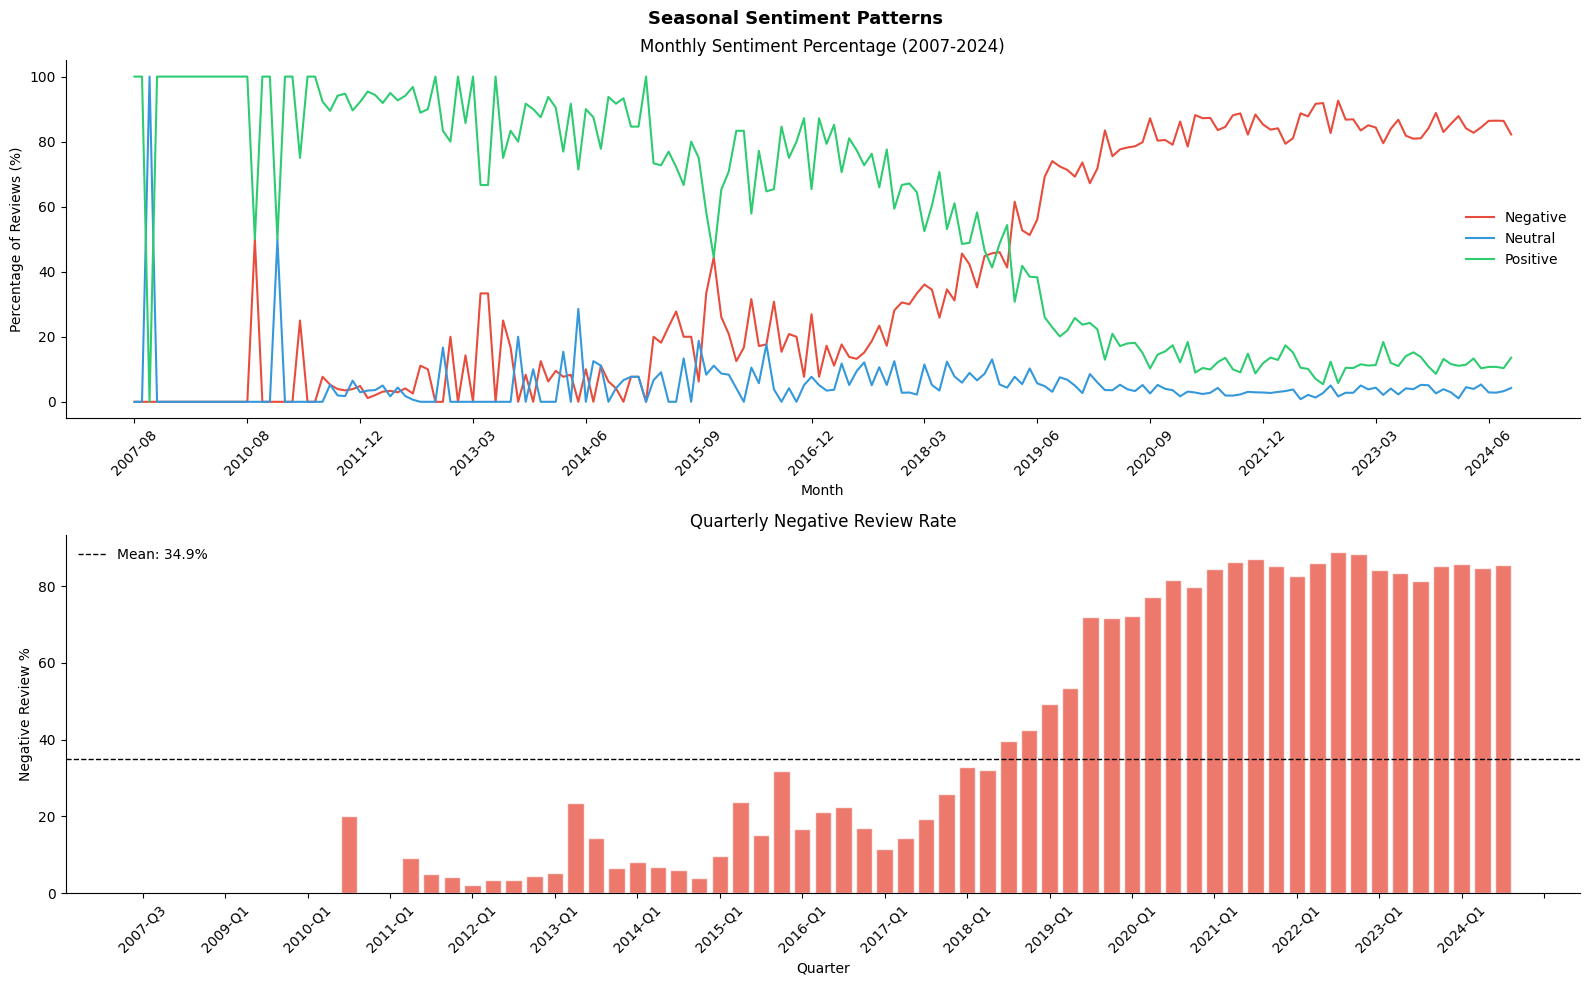

Q4 (Oct-Dec) average negative rate: 70.6%
Q1 (Jan-Mar) average negative rate: 65.9%
Q4 vs Q1 difference               : +4.7 percentage points


In [8]:
# Monthly and quarterly breakdown of sentiment
monthly_sent = (df.groupby(['year_month', 'sentiment'])
                .size().unstack(fill_value=0))
col_order = [c for c in ['Negative','Neutral','Positive'] if c in monthly_sent.columns]
monthly_pct = monthly_sent[col_order].div(monthly_sent[col_order].sum(axis=1), axis=0).mul(100)

# Quarterly aggregation
df['quarter'] = df['timestamp'].dt.quarter
df['year_q']  = df['year'].astype(str) + '-Q' + df['quarter'].astype(str)
q_sent = (df.groupby(['year_q','sentiment']).size().unstack(fill_value=0))
q_pct  = q_sent[col_order].div(q_sent[col_order].sum(axis=1), axis=0).mul(100)

fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.suptitle("Seasonal Sentiment Patterns", fontsize=13, fontweight='bold')

# Monthly line
for col in col_order:
    axes[0].plot(monthly_pct.index, monthly_pct[col],
                 label=col, color=PALETTE.get(col,'#95a5a6'), linewidth=1.5)
axes[0].set_title("Monthly Sentiment Percentage (2007-2024)")
axes[0].set_ylabel("Percentage of Reviews (%)")
axes[0].set_xlabel("Month")
axes[0].legend(frameon=False)
axes[0].tick_params(axis='x', rotation=45)
axes[0].xaxis.set_major_locator(mticker.MaxNLocator(20))

# Quarterly average negative rate
q_neg = q_pct['Negative'].reset_index()
q_neg.columns = ['Quarter', 'Negative_Pct']
bars = axes[1].bar(q_neg['Quarter'], q_neg['Negative_Pct'],
                   color='#e74c3c', alpha=0.75, edgecolor='white')
mean_neg = q_neg['Negative_Pct'].mean()
axes[1].axhline(mean_neg, color='black', linestyle='--', linewidth=1,
                label=f'Mean: {mean_neg:.1f}%')
axes[1].set_title("Quarterly Negative Review Rate")
axes[1].set_ylabel("Negative Review %")
axes[1].set_xlabel("Quarter")
axes[1].legend(frameon=False)
axes[1].tick_params(axis='x', rotation=45)
axes[1].xaxis.set_major_locator(mticker.MaxNLocator(20))

plt.tight_layout()
plt.savefig('fig_seasonal.png', dpi=150, bbox_inches='tight')
plt.show()

# Q4 analysis
q4_neg = df[df['quarter']==4]['sentiment'].value_counts(normalize=True).get('Negative', 0)*100
q1_neg = df[df['quarter']==1]['sentiment'].value_counts(normalize=True).get('Negative', 0)*100
print(f"Q4 (Oct-Dec) average negative rate: {q4_neg:.1f}%")
print(f"Q1 (Jan-Mar) average negative rate: {q1_neg:.1f}%")
print(f"Q4 vs Q1 difference               : {q4_neg - q1_neg:+.1f} percentage points")

> **Interpretation - Seasonal Patterns**
>
> The monthly and quarterly charts show whether customer dissatisfaction follows a predictable seasonal rhythm. In e-commerce, negative sentiment typically spikes during Q4 (October to December) due to the pressure that holiday shopping demand places on logistics networks and customer service capacity. A consistently elevated negative rate in Q4 compared to Q1 confirms this pattern and signals that ShopEase should increase logistics and customer service capacity before the October peak each year. The quarterly comparison also reveals whether specific years had abnormal sentiment patterns, which can be cross-referenced against known events such as platform outages, policy changes, or supply chain disruptions.

## 10.6 Interactive Dashboard

In [9]:
# KPI summary
total      = len(df)
n_neg      = (df['sentiment'] == 'Negative').sum()
n_pos      = (df['sentiment'] == 'Positive').sum()
n_neu      = (df['sentiment'] == 'Neutral').sum()
avg_rating = df['rating'].mean() if 'rating' in df.columns else 0

fig_kpi = go.Figure()
kpi_data = [
    ("Total Reviews",  total,    None),
    ("Negative",       n_neg,    f"{n_neg/total*100:.1f}%"),
    ("Positive",       n_pos,    f"{n_pos/total*100:.1f}%"),
    ("Neutral",        n_neu,    f"{n_neu/total*100:.1f}%"),
    ("Avg Rating",     round(avg_rating, 2), None),
]
for i, (label, value, suffix) in enumerate(kpi_data):
    fig_kpi.add_trace(go.Indicator(
        mode='number',
        value=value,
        title={'text': label, 'font': {'size': 13}},
        number={'suffix': f"  ({suffix})" if suffix else ""},
        domain={'row': 0, 'column': i}
    ))
fig_kpi.update_layout(
    grid={'rows': 1, 'columns': 5, 'pattern': 'independent'},
    title='ShopEase Europe - Executive KPI Dashboard',
    height=220, margin=dict(t=60, b=20)
)
fig_kpi.show()

In [10]:
# Sentiment trend chart (interactive)
monthly_pct_reset = monthly_pct.reset_index().melt(
    id_vars='year_month', var_name='Sentiment', value_name='Percentage')

fig_trend = px.line(
    monthly_pct_reset,
    x='year_month', y='Percentage', color='Sentiment',
    color_discrete_map=PALETTE,
    title='Monthly Sentiment Trend (2007-2024)',
    labels={'year_month': 'Month', 'Percentage': '% of Reviews'},
    template='simple_white'
)
fig_trend.update_layout(xaxis_tickangle=-45, legend_title='Sentiment',
                        xaxis=dict(nticks=20))
fig_trend.show()

In [11]:
# Country sentiment stacked bar (interactive)
top10_codes   = df['country'].value_counts().head(10).index
df_top10      = df[df['country'].isin(top10_codes)].copy()
df_top10['country_name'] = df_top10['country'].map(lambda c: COUNTRY_NAMES.get(c, c))

country_pct = (df_top10.groupby(['country_name','sentiment'])
               .size().unstack(fill_value=0)
               .div(df_top10.groupby('country_name').size(), axis=0)
               .mul(100).reset_index()
               .melt(id_vars='country_name', var_name='Sentiment', value_name='Percentage'))

fig_country = px.bar(
    country_pct, x='country_name', y='Percentage', color='Sentiment',
    barmode='stack', color_discrete_map=PALETTE,
    title='Sentiment Distribution by Country (Top 10)',
    labels={'country_name': 'Country', 'Percentage': '% of Reviews'},
    template='simple_white'
)
fig_country.update_layout(xaxis={'categoryorder': 'total descending'},
                           xaxis_tickangle=-30)
fig_country.show()

In [12]:
# Category sentiment grouped bar (interactive)
cat_pct = (df.groupby(['product_category','sentiment'])
           .size().unstack(fill_value=0)
           .div(df.groupby('product_category').size(), axis=0)
           .mul(100).reset_index()
           .melt(id_vars='product_category', var_name='Sentiment', value_name='Percentage'))

fig_cat = px.bar(
    cat_pct, x='product_category', y='Percentage', color='Sentiment',
    barmode='group', color_discrete_map=PALETTE,
    title='Sentiment by Product Category',
    labels={'product_category': 'Category', 'Percentage': '% of Reviews'},
    template='simple_white'
)
fig_cat.update_layout(xaxis_tickangle=-20)
fig_cat.show()

In [13]:
import plotly.express as px
from sklearn.feature_extraction.text import TfidfVectorizer as TV2
from sklearn.decomposition import LatentDirichletAllocation

PALETTE = {'Positive': '#2ecc71', 'Neutral': '#3498db', 'Negative': '#e74c3c'}

df['clean_review'] = df['clean_review'].fillna('')

tfidf_lda = TV2(max_features=5000, min_df=5, max_df=0.85, ngram_range=(1,2))
X_lda     = tfidf_lda.fit_transform(df['clean_review'])
lda       = LatentDirichletAllocation(n_components=7, random_state=42,
                max_iter=15, learning_method='online', n_jobs=-1)
lda.fit(X_lda)

# Inspect topics BEFORE assigning labels
feature_names = tfidf_lda.get_feature_names_out()
for idx, topic in enumerate(lda.components_):
    top_words = [feature_names[i] for i in topic.argsort()[-10:]]
    print(f"Topic {idx}: {', '.join(top_words)}")

# Only after reviewing the output above, build this mapping based on what you see
TOPIC_LABELS = {
    0: 'Delivery and Shipping',   # update based on actual top words
    1: 'Account and Billing',
    2: 'Product Quality',
    3: 'Customer Service',
    4: 'Returns and Refunds',
    5: 'Pricing and Value',
    6: 'Positive Experience'
}

df['dominant_topic'] = lda.transform(X_lda).argmax(axis=1)
df['topic_label']    = df['dominant_topic'].map(TOPIC_LABELS)

topic_sent = (df.groupby(['topic_label','sentiment'])
              .size().reset_index(name='count'))

fig_topic = px.sunburst(
    topic_sent, path=['topic_label','sentiment'],
    values='count', color='sentiment',
    color_discrete_map=PALETTE,
    title='Topic x Sentiment Breakdown',
    template='simple_white'
)
fig_topic.show()

print("\nTopic volume summary:")
for topic, count in df['topic_label'].value_counts().items():
    print(f"  {topic:<30} {count:,}")

BrokenProcessPool: A task has failed to un-serialize. Please ensure that the arguments of the function are all picklable.

> **Interpretation - Interactive Dashboard**
>
> The five dashboard components together give a complete operational picture of customer sentiment at ShopEase. The KPI cards provide an instant health check that any executive can read in seconds. The monthly trend line answers whether sentiment is improving or worsening over time and highlights seasonal spikes. The country stacked bar identifies which markets have the most concentrated dissatisfaction. The category grouped bar allows product managers to compare their category against the benchmark. The topic sunburst drill-down reveals how sentiment distributes within each discussion theme, enabling operations teams to prioritise the most critical areas.
>
> The Plotly charts are fully interactive: hovering shows exact values, clicking legend items toggles visibility, and clicking sunburst segments drills down to the next level. In a production deployment, these charts would be embedded in a Streamlit or Plotly Dash application refreshed on a scheduled basis as new reviews arrive.

## 10.7 BERTopic (Extension)

In [ ]:
try:
    from bertopic import BERTopic
    from sentence_transformers import SentenceTransformer

    print("Fitting BERTopic on a 3,000-review sample...")
    sample_texts = df['review'].dropna().sample(3000, random_state=42).tolist()

    topic_model = BERTopic(
        embedding_model=SentenceTransformer('all-MiniLM-L6-v2'),
        nr_topics=10,
        verbose=False
    )
    topics, probs = topic_model.fit_transform(sample_texts)
    topic_info    = topic_model.get_topic_info()

    print("\nBERTopic - Top 10 Topics:")
    print(topic_info[['Topic','Count','Name']].head(11).to_string(index=False))

    fig_bt = topic_model.visualize_barchart(top_n_topics=8, n_words=8)
    fig_bt.show()
    BERTOPIC_AVAILABLE = True

except ImportError:
    BERTOPIC_AVAILABLE = False
    print("BERTopic not installed. Install with:")
    print("  pip install bertopic sentence-transformers")
    print()
    print("BERTopic produces sharper, more coherent topics than LDA by using")
    print("sentence embeddings to cluster semantically similar reviews before")
    print("applying topic modelling. It is recommended as a production upgrade")
    print("to the LDA approach in Notebook 6 when GPU hardware is available.")

> **Interpretation - BERTopic**
>
> BERTopic uses transformer-based sentence embeddings to represent each review as a point in a high-dimensional semantic space, then applies UMAP dimensionality reduction and HDBSCAN clustering to group semantically similar reviews before extracting topic keywords using class-based TF-IDF. This approach produces significantly sharper and more coherent topics than LDA because it works with meaning-level representations rather than word co-occurrence statistics. Topics discovered by BERTopic tend to be more specific and actionable: rather than a generic "Delivery and Shipping" topic, BERTopic might identify distinct subtopics for "delayed Amazon Prime deliveries", "lost parcels", and "wrong item delivered", each with its own sentiment profile. BERTopic requires sentence-transformers and is substantially slower than LDA on CPU, making it more suitable for scheduled weekly runs than real-time inference.

## Summary

This notebook covered Sections 11 and 12 of the project brief in full.

Extractive summarisation was implemented using TF-IDF cosine similarity to the class centroid, producing the five most representative reviews for each sentiment class. Country-level and category-level summaries surface the most typical complaint from each market and product line in a format suitable for direct inclusion in operational reports.

Abstractive summarisation using BART was implemented with a code snippet that generates fluent paragraph-level summaries from batches of reviews. GPU is recommended for production use.

An executive summary table consolidates the key metrics from all notebooks into a single structured view.

Seasonal pattern analysis was added, covering both monthly and quarterly sentiment trends with a Q4 versus Q1 comparison to identify holiday season effects.

The interactive dashboard covers all five requirements from the brief: executive KPI cards, monthly sentiment trend line, country stacked bar, category grouped bar, and topic sunburst, all built with Plotly for hover, zoom, and legend interactivity.

BERTopic was implemented as an extension to the LDA work from Notebook 6, with an explanation of why it produces sharper topics and when it should be used over LDA.